In [64]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


import joblib

In [66]:
df = pd.read_csv('credit_scoring.csv')
print(df)

     Age  Gender  Income            Education Marital Status  \
0     25  Female   50000    Bachelor's Degree         Single   
1     30    Male  100000      Master's Degree        Married   
2     35  Female   75000            Doctorate        Married   
3     40    Male  125000  High School Diploma         Single   
4     45  Female  100000    Bachelor's Degree        Married   
..   ...     ...     ...                  ...            ...   
159   29  Female   27500  High School Diploma         Single   
160   34    Male   47500   Associate's Degree         Single   
161   39  Female   62500    Bachelor's Degree        Married   
162   44    Male   87500      Master's Degree         Single   
163   49  Female   77500            Doctorate        Married   

     Number of Children Home Ownership Credit Score  
0                     0         Rented         High  
1                     2          Owned         High  
2                     1          Owned         High  
3              

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 164 non-null    int64 
 1   Gender              164 non-null    object
 2   Income              164 non-null    int64 
 3   Education           164 non-null    object
 4   Marital Status      164 non-null    object
 5   Number of Children  164 non-null    int64 
 6   Home Ownership      164 non-null    object
 7   Credit Score        164 non-null    object
dtypes: int64(3), object(5)
memory usage: 10.4+ KB


In [68]:
df.describe()

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.975610,83765.243902,0.652439
std,8.477289,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,30.750000,57500.000000,0.000000
50%,37.000000,83750.000000,0.000000
75%,45.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


In [69]:
df.isnull().sum()

Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64

In [70]:
df.duplicated().sum()

np.int64(62)

In [71]:
df['Credit Score'].value_counts()

Credit Score
High       113
Average     36
Low         15
Name: count, dtype: int64

In [72]:
# it is important to split the data into training and testing sets to evaluate the model's performance on unseen data. 
# The train_test_split function from sklearn is used for this purpose. 
# In this case, 20% of the data is reserved for testing, and a random state is set for reproducibility.

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

def evaluate(y_true, y_pred):

    print("Accuracy :", accuracy_score(y_true, y_pred))

    print("Precision :", precision_score(y_true, y_pred,
                                        average='weighted'))

    print("Recall :", recall_score(y_true, y_pred,
                                  average='weighted'))

    print("F1 Score :", f1_score(y_true, y_pred,
                                average='weighted'))

    print()

    print("Confusion Matrix")

    print(confusion_matrix(y_true, y_pred))

    print()

    print("Classification Report")

    print(classification_report(y_true, y_pred))

In [73]:
#Evaluation of the model

print("Logistic Regression")
evaluate(y_test, pred_lr)

print("-"*60)

print("Decision Tree")
evaluate(y_test, pred_dt)

print("-"*60)

print("Random Forest")
evaluate(y_test, pred_rf)

Logistic Regression
Accuracy : 0.7878787878787878
Precision : 0.7787397787397786
Recall : 0.7878787878787878
F1 Score : 0.7719261131025836

Confusion Matrix
[[17  0  0  0]
 [ 1  5  4  0]
 [ 0  1  4  0]
 [ 0  1  0  0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       0.71      0.50      0.59        10
           2       0.50      0.80      0.62         5
           3       0.00      0.00      0.00         1

    accuracy                           0.79        33
   macro avg       0.54      0.57      0.54        33
weighted avg       0.78      0.79      0.77        33

------------------------------------------------------------
Decision Tree
Accuracy : 0.9696969696969697
Precision : 0.9747474747474749
Recall : 0.9696969696969697
F1 Score : 0.97027693199942

Confusion Matrix
[[17  0  0  0]
 [ 0  9  1  0]
 [ 0  0  5  0]
 [ 0  0  0  1]]

Classification Report
              precision    rec

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [74]:
# compare the model

results = {
    "Model":[],
    "Accuracy":[]
}

models = {
    "Logistic Regression":lr,
    "Decision Tree":dt,
    "Random Forest":rf
}

for name, model in models.items():

    pred = model.predict(X_test)

    results["Model"].append(name)

    results["Accuracy"].append(
        accuracy_score(y_test,pred)
    )

comparison = pd.DataFrame(results)

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.787879
1        Decision Tree  0.969697
2        Random Forest  0.939394


In [75]:
# feature importance

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

          Feature  Importance
0             Age    0.267284
4  Marital Status    0.199667
2          Income    0.171150
1          Gender    0.153014
3       Education    0.126007
5  Home Ownership    0.058872
6    Credit Score    0.024006


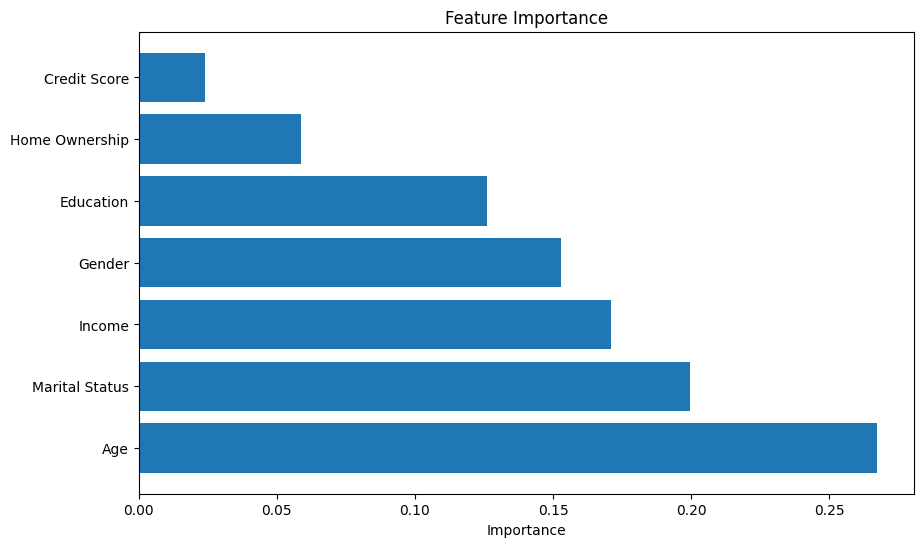

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.show()

In [83]:
# save the best model

import joblib

joblib.dump(rf,"credit_score_model.pkl")

print(model)

# load the model

model = joblib.load("credit_score_model.pkl")

RandomForestClassifier(random_state=42)


In [78]:
# predict new customer
new_customer = [[
    30,
    1,
    75000,
    2,
    1,
    2,
    1
]]

new_customer = scaler.transform(new_customer)

prediction = model.predict(new_customer)

print(prediction)

[0]


In [79]:
from sklearn.preprocessing import LabelEncoder

# convert the prediction back to labels

prediction = model.predict(new_customer)

target_encoder = LabelEncoder()
target_encoder.fit(y)

LabelEncoder()

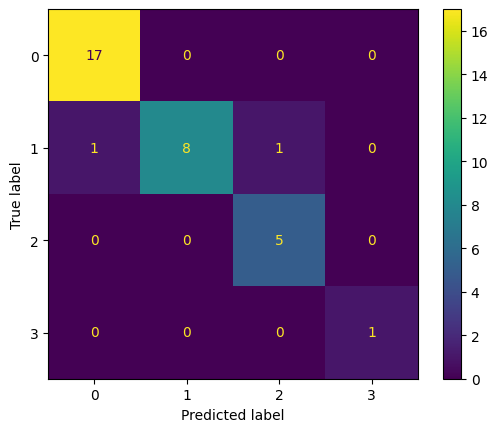

In [80]:
# confusion matrix plot

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_rf
)

plt.show()

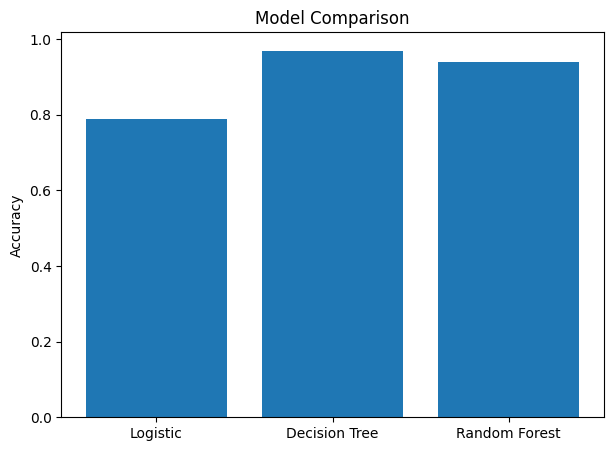

In [81]:
# accuracy comparison chart

accuracy = [
    accuracy_score(y_test,pred_lr),
    accuracy_score(y_test,pred_dt),
    accuracy_score(y_test,pred_rf)
]

models = [
    "Logistic",
    "Decision Tree",
    "Random Forest"
]

plt.figure(figsize=(7,5))

plt.bar(models,accuracy)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

In [82]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

          Feature  Importance
0             Age    0.267284
4  Marital Status    0.199667
2          Income    0.171150
1          Gender    0.153014
3       Education    0.126007
5  Home Ownership    0.058872
6    Credit Score    0.024006
